# 02. Unsupervised Anomaly Detection (Isolation Forest)

본 노트북은 scikit-learn의 `IsolationForest` 모델을 활용하여 로그 데이터의 비지도 학습 이상치 탐지(Anomaly Detection)를 수행하고 최적의 `contamination` 비율을 튜닝하는 실습 공간입니다.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score

# 프로젝트 루트 경로를 sys.path에 추가하여 src 패키지를 찾을 수 있도록 함
sys.path.append(os.path.abspath(os.path.join("..")))

from src.parser import LogParser
from src.detector import AnomalyDetector

# 한글 폰트 설정 (추가됨)
import platform

if platform.system() == "Darwin":  # Mac
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":  # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 1. 전처리 데이터 로드

In [2]:
SSD_PATH = "/Volumes/T7/LogSentinel_Data/raw/"
# CWD가 notebooks 디렉토리일 경우를 고려하여 프로젝트 루트 기준으로 상대경로를 절대경로로 변환합니다.
LOCAL_PATH = os.path.abspath(os.path.join("..", "data", "raw"))

def get_data_path(filename):
    ssd_file = os.path.join(SSD_PATH, filename)
    local_file = os.path.join(LOCAL_PATH, filename)
    if os.path.exists(ssd_file):
        return ssd_file
    return local_file

log_file_path = get_data_path("BGL_2k.log")

data = []
with open(log_file_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 10: 
            continue
        label = parts[0]
        is_anomaly = 1 if label != "-" else 0
        message = " ".join(parts[9:])
        data.append({"is_anomaly": is_anomaly, "raw_message": message})

df = pd.DataFrame(data)
print(f"Loaded {len(df)} logs.")

Loaded 2000 logs.


In [3]:
data

[{'is_anomaly': 0, 'raw_message': 'instruction cache parity error corrected'},
 {'is_anomaly': 0, 'raw_message': 'instruction cache parity error corrected'},
 {'is_anomaly': 0, 'raw_message': 'instruction cache parity error corrected'},
 {'is_anomaly': 0, 'raw_message': 'instruction cache parity error corrected'},
 {'is_anomaly': 0, 'raw_message': '63543 double-hummer alignment exceptions'},
 {'is_anomaly': 0, 'raw_message': '162 double-hummer alignment exceptions'},
 {'is_anomaly': 0, 'raw_message': '141 double-hummer alignment exceptions'},
 {'is_anomaly': 0, 'raw_message': 'CE sym 2, at 0x0b85eee0, mask 0x05'},
 {'is_anomaly': 1,
  'raw_message': 'ciod: failed to read message prefix on control stream (CioStream socket to 172.16.96.116:33569'},
 {'is_anomaly': 1,
  'raw_message': 'ciod: failed to read message prefix on control stream (CioStream socket to 172.16.96.116:33370'},
 {'is_anomaly': 0, 'raw_message': 'CE sym 20, at 0x1438f9e0, mask 0x40'},
 {'is_anomaly': 0, 'raw_message': 

## 2. 파싱 및 TF-IDF 수치화

In [4]:
parser = LogParser(max_features=500)
df["cleaned_message"] = df["raw_message"].apply(parser.clean_log)
X = parser.fit_transform(df["cleaned_message"])
y = df["is_anomaly"].values

In [5]:
X.shape

(2000, 500)

In [6]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [7]:
y.shape

(2000,)

In [8]:
y

array([0, 0, 0, ..., 0, 0, 0])

## 3. Isolation Forest 학습 및 오염도(contamination) 하이퍼파라미터 스캔

In [9]:
# 경로 설정 및 방어 코딩 (T7 SSD 장착 여부 확인)
SSD_MODELS_PATH = "/Volumes/T7/LogSentinel_Data/models"
LOCAL_MODELS_PATH = os.path.abspath(os.path.join("..", "models"))
ANOMAL_DETECT_EVAL_FILE = 'confusion_matrix_and_rocauc_2k_per_c.txt'

# T7 SSD 디렉토리가 존재하는지 확인
if os.path.exists("/Volumes/T7"):
    models_dir = SSD_MODELS_PATH
else:
    models_dir = LOCAL_MODELS_PATH

os.makedirs(models_dir, exist_ok=True)
anomal_detection_eval_file = os.path.join(models_dir, ANOMAL_DETECT_EVAL_FILE)

contamination_ratios = [0.01, 0.05, 0.075, 0.1, 0.15]

# 파일에 저장할 데이터 헤더 작성 및 쓰기 준비
try:
    with open(anomal_detection_eval_file, "w", encoding="utf-8") as f:
        f.write("contamination,tn,fp,fn,tp,roc_auc\n")  # Header 행
    print(f"Metrics file initialized at: {anomal_detection_eval_file}")
except Exception as e:
    print(f"Failed to initialize metrics file at {anomal_detection_eval_file}: {e}")

for c in contamination_ratios:
    detector = AnomalyDetector(contamination=c)
    detector.train(X)
    preds = detector.predict(X)
    pred_anomaly = (preds == -1).astype(int)
    
    print(f"\n[Contamination: {c}]")
    tn, fp, fn, tp = confusion_matrix(y, pred_anomaly).ravel()
    print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    # ROC AUC Score
    scores = -detector.get_anomaly_scores(X) # 높은 값이 아노말리를 나타내도록 부호 반전
    roc_auc = roc_auc_score(y, scores)
    print(f"ROC AUC Score: {roc_auc:.4f}")
    
    # 구분자(,)를 포함하여 파일에 추가 저장
    try:
        with open(anomal_detection_eval_file, "a", encoding="utf-8") as f:
            f.write(f"{c},{tn},{fp},{fn},{tp},{roc_auc:.4f}\n") # Data 행들
    except Exception as e:
        print(f"Failed to append metric for contamination {c} to file: {e}")

Metrics file initialized at: /Users/soromiso/Desktop/Dev/soromiso/LogSentinel/models/confusion_matrix_and_rocauc_2k_per_c.txt

[Contamination: 0.01]
Confusion Matrix: TN=1857, FP=0, FN=143, TP=0
ROC AUC Score: 0.6525

[Contamination: 0.05]
Confusion Matrix: TN=1762, FP=95, FN=140, TP=3
ROC AUC Score: 0.6525

[Contamination: 0.075]
Confusion Matrix: TN=1716, FP=141, FN=138, TP=5
ROC AUC Score: 0.6525

[Contamination: 0.1]
Confusion Matrix: TN=1712, FP=145, FN=129, TP=14
ROC AUC Score: 0.6525

[Contamination: 0.15]
Confusion Matrix: TN=1588, FP=269, FN=112, TP=31
ROC AUC Score: 0.6525


Metrics successfully loaded from: /Users/soromiso/Desktop/Dev/soromiso/LogSentinel/models/confusion_matrix_and_rocauc_2k_per_c.txt
   contamination    tn   fp   fn  tp  roc_auc
0          0.010  1857    0  143   0   0.6525
1          0.050  1762   95  140   3   0.6525
2          0.075  1716  141  138   5   0.6525
3          0.100  1712  145  129  14   0.6525
4          0.150  1588  269  112  31   0.6525


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


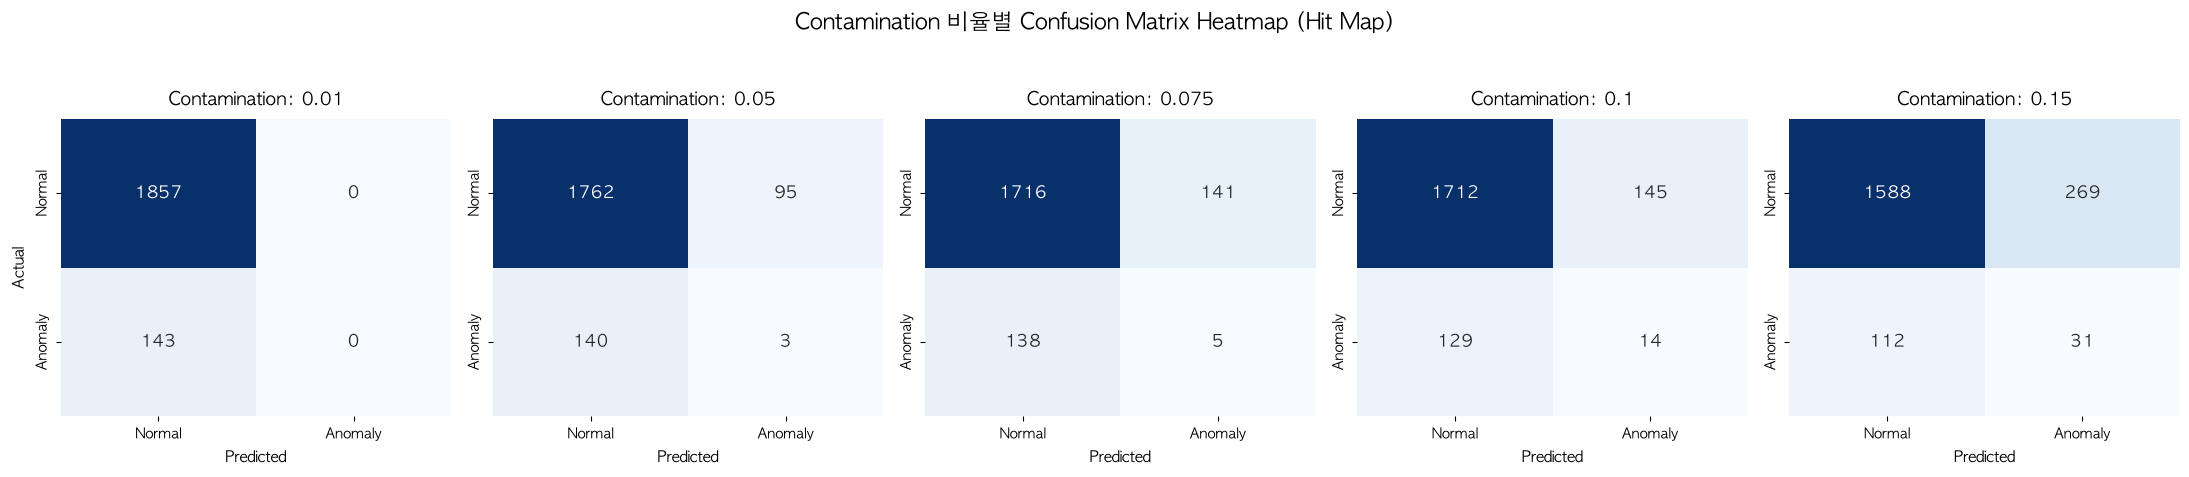

findfont: Failed to find font weight bold, now using 400.


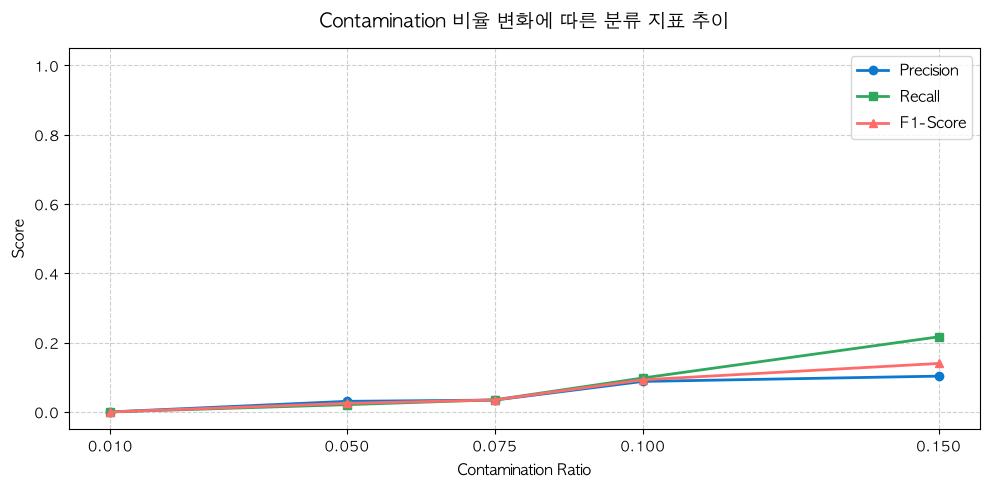

In [10]:
# 12번째 셀: 파일에서 결과 읽어와 시각화 수행
import os
import matplotlib.pyplot as plt
import pandas as pd

# 경로 설정 및 방어 코딩 (11번째 셀의 파일 위치 탐색)
SSD_MODELS_PATH = "/Volumes/T7/LogSentinel_Data/models"
LOCAL_MODELS_PATH = os.path.abspath(os.path.join("..", "models"))
ANOMAL_DETECT_EVAL_FILE = 'confusion_matrix_and_rocauc_2k_per_c.txt'

if os.path.exists("/Volumes/T7"):
    models_dir = SSD_MODELS_PATH
else:
    models_dir = LOCAL_MODELS_PATH

anomal_detection_eval_file = os.path.join(models_dir, ANOMAL_DETECT_EVAL_FILE)

# 파일 읽기 및 시각화
try:
    # pandas로 CSV 형식의 텍스트 파일을 바로 로드
    df_metrics = pd.read_csv(anomal_detection_eval_file)
    print(f"Metrics successfully loaded from: {anomal_detection_eval_file}")
    print(df_metrics)
    
    # 1. Confusion Matrix Heatmaps 시각화 (1x5 Subplots)
    fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
    fig.suptitle("Contamination 비율별 Confusion Matrix Heatmap (Hit Map)", fontsize=16, fontweight="bold", y=1.05)
    
    for i, row in df_metrics.iterrows():
        c = row["contamination"]
        tn, fp, fn, tp = int(row["tn"]), int(row["fp"]), int(row["fn"]), int(row["tp"])
        
        cm = np.array([
            [tn, fp],
            [fn, tp]
        ])
        
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i],
            xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"],
            annot_kws={"size": 12, "weight": "bold"}
        )
        axes[i].set_title(f"Contamination: {c}", fontsize=13, fontweight="bold", pad=10)
        axes[i].set_xlabel("Predicted", fontsize=11)
        if i == 0:
            axes[i].set_ylabel("Actual", fontsize=11)
        else:
            axes[i].set_ylabel("")
            
    plt.tight_layout()
    plt.show()
    
    # 2. 성능 지표 추이 그래프 (Precision, Recall, F1-Score)
    contaminations = df_metrics["contamination"].tolist()
    precisions = []
    recalls = []
    f1_scores = []
    
    for i, row in df_metrics.iterrows():
        tp, fp, fn = row["tp"], row["fp"], row["fn"]
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
        
    plt.figure(figsize=(10, 5))
    plt.plot(contaminations, precisions, marker='o', label='Precision', color='#0B79D0', linewidth=2)
    plt.plot(contaminations, recalls, marker='s', label='Recall', color='#2FA85D', linewidth=2)
    plt.plot(contaminations, f1_scores, marker='^', label='F1-Score', color='#FF6B6B', linewidth=2)
    
    plt.title("Contamination 비율 변화에 따른 분류 지표 추이", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Contamination Ratio", fontsize=11)
    plt.ylabel("Score", fontsize=11)
    plt.xticks(contaminations)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error loading metrics or generating plots: {e}")

### 💡 분석 요약 및 대책
2k 소량 샘플에서는 비지도 학습 특성상 정상 로그 중 복잡한 숫자를 가진 소량의 고유 패턴(예: `generating core.[NUM]`)이 아노말리로 오탐(FP)되고, 실제 고정 템플릿을 지닌 장애 로그가 정상 분포로 오분류되어 **TP가 0**이 되는 경향이 있습니다.
이를 극복하기 위해:
1. **BGL 전체 데이터셋(470만 행)** 투입: 정상 로그의 반복 빈도가 막대해지면 데이터 공간상에서 매우 두터운 클러스터를 형성하므로, 장애 로그가 정상 클러스터 바깥으로 완전히 밀려나 이상치로 탐지되기 시작합니다.
2. **임베딩 방식 보완**: TF-IDF 피처 차원을 정밀 튜닝하거나, 4단계의 LSTM에서 시퀀스 흐름(선후 맥락) 정보를 보완 학습시킵니다.

In [11]:
# 최종 이상 탐지(Isolation Forest) 모델 학습 및 직렬화 저장
import os

# CWD가 notebooks 디렉토리일 경우를 고려하여 프로젝트 루트 기준으로 상대경로를 절대경로로 변환합니다.
LOCAL_PATH = os.path.abspath(os.path.join("..", "models"))
os.makedirs(LOCAL_PATH, exist_ok=True)
model_save_path = os.path.join(LOCAL_PATH, "iso_forest.pkl")

# 최적의 contamination 비율로 모델 학습
best_contamination = 0.1
detector = AnomalyDetector(contamination=best_contamination)
detector.train(X)

# 모델 저장
detector.save_model(model_save_path)
print(f"Anomaly detector model successfully saved at: {model_save_path}")

Anomaly detector model successfully saved at: /Users/soromiso/Desktop/Dev/soromiso/LogSentinel/models/iso_forest.pkl
